# Task 6 Notebook: Cross-Validation & Ablation

This notebook is designed by **Thandeka**.

It uses the latest group files and keeps the whole exercise in Jupyter.

## What this notebook does

1. Loads the week 2, 4, 6, and 8 processed feature tables.
2. Loads the Task 4 baseline results, if available.
3. Loads the saved model inspection summary, if available.
4. Re-runs the official Task 4 baseline model families using 5-fold stratified CV.
5. Runs Task 6 feature-drop ablation.
6. Runs Task 6 encoding ablation.
7. Runs advanced / Task 5-style model CV by recreating the model definitions inside CV folds.
8. Produces report-ready CSV tables and PNG figures.


## 1. Imports and global settings

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

try:
    from sklearn.calibration import CalibratedClassifierCV
    HAS_CALIBRATION = True
except Exception:
    HAS_CALIBRATION = False

try:
    from sklearn.preprocessing import TargetEncoder
    HAS_TARGET_ENCODER = True
except Exception:
    HAS_TARGET_ENCODER = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
CV_FOLDS = 5

WEEKS = ["week2", "week4", "week6", "week8"]
WEEK_NUM = {"week2": 2, "week4": 4, "week6": 6, "week8": 8}

TARGET = "label"
ID_COLS = ["id_student", "code_module", "code_presentation"]

DEMO_CAT_COLS = ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]
DEMO_NUM_COLS = ["num_of_prev_attempts", "studied_credits"]

VLE_ACT_TYPES = [
    "oucontent", "quiz", "resource", "homepage",
    "subpage", "glossary", "oucollaborate", "forumng",
]

# This is False to align with the latest Task 4 script, which drops
# id_student, code_module, and code_presentation before modelling.

INCLUDE_MODULE_PRESENTATION_AS_FEATURES = False

Path("results").mkdir(exist_ok=True)

print("XGBoost available:", HAS_XGBOOST)
print("CatBoost available:", HAS_CATBOOST)
print("TargetEncoder available:", HAS_TARGET_ENCODER)


XGBoost available: True
CatBoost available: False
TargetEncoder available: True


## 2. Locate project files

In [2]:
def first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None

def find_feature_file(week: str) -> Path:
    candidates = [
        Path("data") / "processed" / f"{week}_features.csv",
        Path(f"{week}_features.csv"),
        Path("processed") / f"{week}_features.csv",
    ]
    path = first_existing(candidates)
    if path is None:
        raise FileNotFoundError(f"Could not find {week}_features.csv")
    return path

task4_results_path = first_existing([
    "data/processed/task4_baseline_results.csv",
    "task4_baseline_results.csv",
])

model_inspection_path = first_existing([
    "data/processed/model_inspection_summary.csv",
    "model_inspection_summary.csv",
])

print("Task 4 results:", task4_results_path)
print("Model inspection summary:", model_inspection_path)

for week in WEEKS:
    print(week, "->", find_feature_file(week))


Task 4 results: None
Model inspection summary: None
week2 -> data\processed\week2_features.csv
week4 -> data\processed\week4_features.csv
week6 -> data\processed\week6_features.csv
week8 -> data\processed\week8_features.csv


## 3. Load the week feature tables

In [3]:
def load_week_df(week: str) -> pd.DataFrame:
    df = pd.read_csv(find_feature_file(week))
    if TARGET not in df.columns:
        raise ValueError(f"{week} file does not contain target column: {TARGET}")
    return df

def split_xy(df: pd.DataFrame):
    drop_cols = [TARGET, "id_student"]
    if not INCLUDE_MODULE_PRESENTATION_AS_FEATURES:
        drop_cols += ["code_module", "code_presentation"]
    drop_cols = [c for c in drop_cols if c in df.columns]

    X = df.drop(columns=drop_cols)
    y = df[TARGET].astype(int)
    return X, y

summary_rows = []
for week in WEEKS:
    df = load_week_df(week)
    X, y = split_xy(df)
    summary_rows.append({
        "week": week,
        "rows": len(df),
        "features_used": X.shape[1],
        "favourable_1": int((y == 1).sum()),
        "unfavourable_0": int((y == 0).sum()),
        "unfavourable_%": round((y == 0).mean() * 100, 2),
    })

data_summary = pd.DataFrame(summary_rows)
data_summary


,week,rows,features_used,favourable_1,unfavourable_0,unfavourable_%
0,week2,32593,18,15385,17208,52.8
1,week4,32593,18,15385,17208,52.8
2,week6,32593,18,15385,17208,52.8
3,week8,32593,18,15385,17208,52.8


## 3B. Exploratory Data Analysis figures

This section adds EDA figures before modelling. These figures help verify the processed week-cutoff datasets and give the report team visual evidence of class balance, VLE engagement over time, missingness, and simple target relationships.


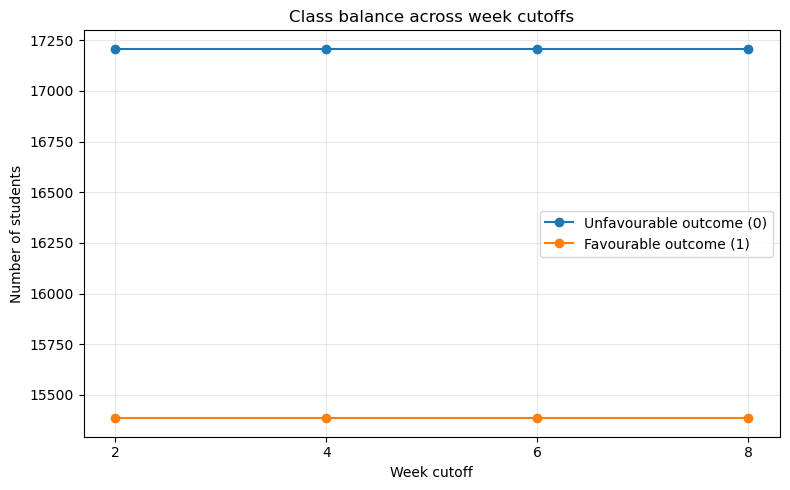

Saved: results/eda_class_balance_by_week.png
Saved: results/eda_class_balance_by_week.csv


,week,unfavourable_0,favourable_1
0,2,17208,15385
1,4,17208,15385
2,6,17208,15385
3,8,17208,15385


In [4]:
# EDA Figure 1: Class balance by week cutoff
class_balance_rows = []

for week in WEEKS:
    df = load_week_df(week)
    counts = df[TARGET].value_counts().sort_index()
    class_balance_rows.append({
        "week": WEEK_NUM[week],
        "unfavourable_0": int(counts.get(0, 0)),
        "favourable_1": int(counts.get(1, 0)),
    })

class_balance = pd.DataFrame(class_balance_rows).sort_values("week")

plt.figure(figsize=(8, 5))
plt.plot(class_balance["week"], class_balance["unfavourable_0"], marker="o", label="Unfavourable outcome (0)")
plt.plot(class_balance["week"], class_balance["favourable_1"], marker="o", label="Favourable outcome (1)")
plt.xlabel("Week cutoff")
plt.ylabel("Number of students")
plt.title("Class balance across week cutoffs")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("results/eda_class_balance_by_week.png", dpi=200)
plt.show()

class_balance.to_csv("results/eda_class_balance_by_week.csv", index=False)
print("Saved: results/eda_class_balance_by_week.png")
print("Saved: results/eda_class_balance_by_week.csv")
class_balance


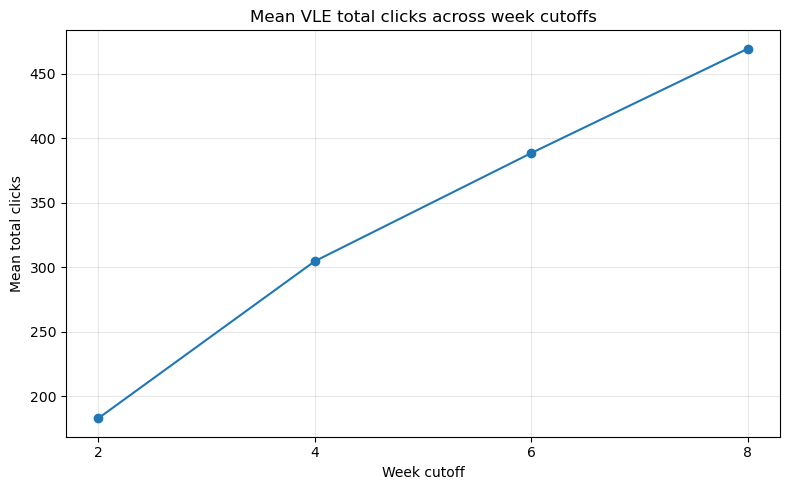

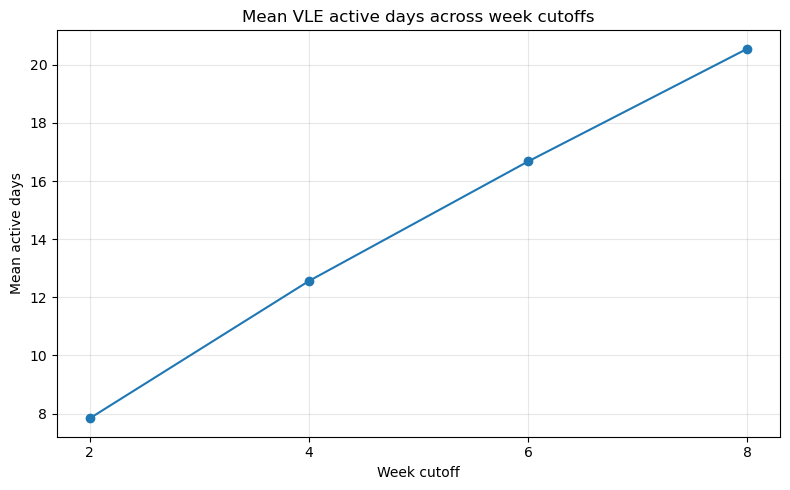

Saved: results/eda_mean_total_clicks_by_week.png
Saved: results/eda_mean_active_days_by_week.png
Saved: results/eda_vle_engagement_summary.csv


,week,mean_total_clicks,mean_active_days
0,2,182.820606,7.839505
1,4,304.646703,12.563280
2,6,388.536956,16.676219
3,8,469.476084,20.552757


In [5]:
# EDA Figure 2: Mean VLE engagement by week
vle_summary_rows = []

for week in WEEKS:
    df = load_week_df(week)
    total_col = f"total_clicks_{week}"
    active_col = f"active_days_{week}"

    vle_summary_rows.append({
        "week": WEEK_NUM[week],
        "mean_total_clicks": float(df[total_col].mean()) if total_col in df.columns else np.nan,
        "mean_active_days": float(df[active_col].mean()) if active_col in df.columns else np.nan,
    })

vle_summary = pd.DataFrame(vle_summary_rows).sort_values("week")

plt.figure(figsize=(8, 5))
plt.plot(vle_summary["week"], vle_summary["mean_total_clicks"], marker="o")
plt.xlabel("Week cutoff")
plt.ylabel("Mean total clicks")
plt.title("Mean VLE total clicks across week cutoffs")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/eda_mean_total_clicks_by_week.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(vle_summary["week"], vle_summary["mean_active_days"], marker="o")
plt.xlabel("Week cutoff")
plt.ylabel("Mean active days")
plt.title("Mean VLE active days across week cutoffs")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/eda_mean_active_days_by_week.png", dpi=200)
plt.show()

vle_summary.to_csv("results/eda_vle_engagement_summary.csv", index=False)
print("Saved: results/eda_mean_total_clicks_by_week.png")
print("Saved: results/eda_mean_active_days_by_week.png")
print("Saved: results/eda_vle_engagement_summary.csv")
vle_summary


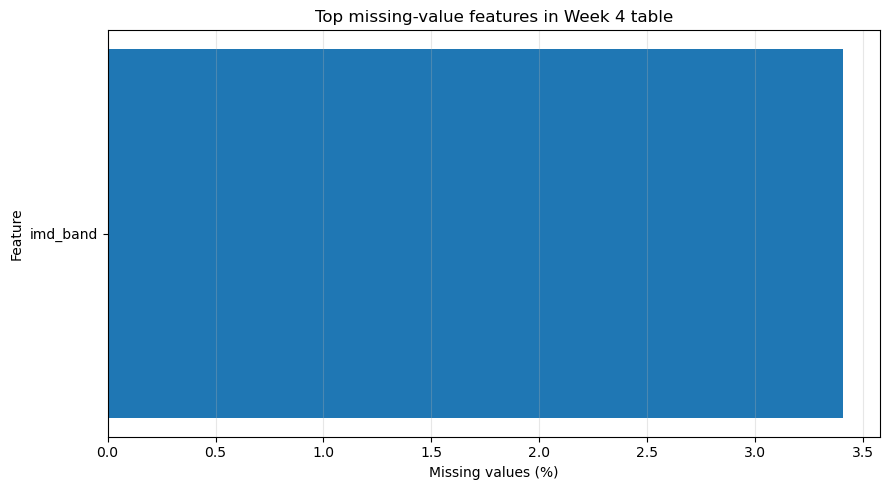

Saved: results/eda_week4_missing_values.png
Saved: results/eda_week4_missing_values.csv


,feature,missing_percent
0,imd_band,3.408707


In [6]:
# EDA Figure 3: Top missing-value columns in Week 4
week_for_missing = "week4"
df_missing = load_week_df(week_for_missing)

missing_percent = (
    df_missing.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

top_missing = missing_percent[missing_percent > 0].head(15)

if len(top_missing) == 0:
    print(f"No missing values found in {week_for_missing}.")
else:
    plt.figure(figsize=(9, 5))
    plt.barh(top_missing.index[::-1], top_missing.values[::-1])
    plt.xlabel("Missing values (%)")
    plt.ylabel("Feature")
    plt.title("Top missing-value features in Week 4 table")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/eda_week4_missing_values.png", dpi=200)
    plt.show()
    print("Saved: results/eda_week4_missing_values.png")

top_missing_df = top_missing.reset_index()
top_missing_df.columns = ["feature", "missing_percent"]
top_missing_df.to_csv("results/eda_week4_missing_values.csv", index=False)
print("Saved: results/eda_week4_missing_values.csv")
top_missing_df


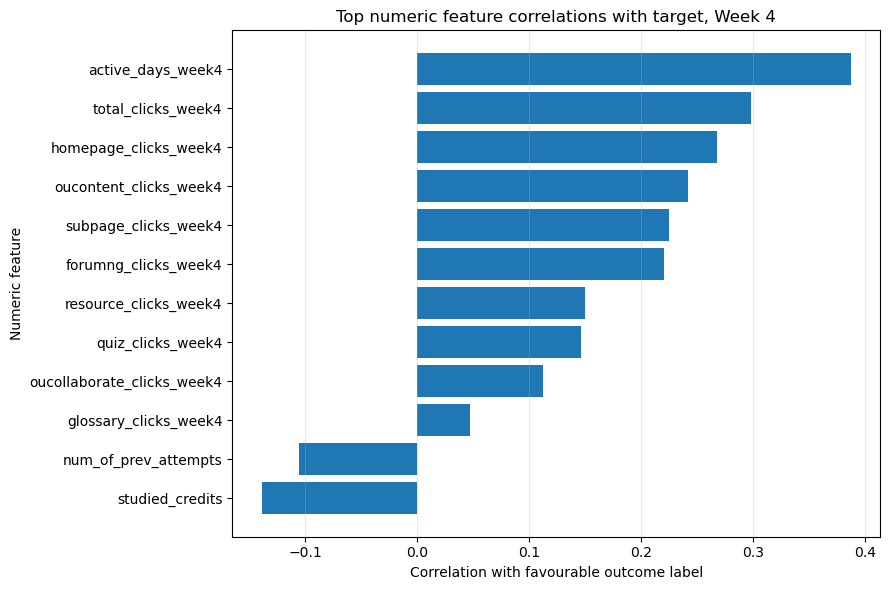

Saved: results/eda_week4_numeric_correlations.png
Saved: results/eda_week4_numeric_correlations.csv


,feature,correlation_with_label,absolute_correlation
3,active_days_week4,0.387156,0.387156
2,total_clicks_week4,0.298202,0.298202
7,homepage_clicks_week4,0.268266,0.268266
4,oucontent_clicks_week4,0.241793,0.241793
8,subpage_clicks_week4,0.225327,0.225327
11,forumng_clicks_week4,0.220593,0.220593
6,resource_clicks_week4,0.150181,0.150181
5,quiz_clicks_week4,0.146117,0.146117
1,studied_credits,-0.138630,0.138630
10,oucollaborate_clicks_week4,0.112783,0.112783


In [7]:
# EDA Figure 4: Numeric feature correlation with target in Week 4
week_for_corr = "week4"
df_corr = load_week_df(week_for_corr)
X_corr, y_corr = split_xy(df_corr)

numeric_cols = X_corr.select_dtypes(include=["int64", "int32", "float64", "float32", "Int64"]).columns.tolist()

corr_rows = []
for col in numeric_cols:
    series = X_corr[col]
    if series.nunique(dropna=True) > 1:
        corr_value = series.corr(y_corr)
        if pd.notna(corr_value):
            corr_rows.append({
                "feature": col,
                "correlation_with_label": float(corr_value),
                "absolute_correlation": float(abs(corr_value)),
            })

corr_df = (
    pd.DataFrame(corr_rows)
    .sort_values("absolute_correlation", ascending=False)
    .head(15)
)

if len(corr_df) == 0:
    print("No numeric correlations available.")
else:
    plot_df = corr_df.sort_values("correlation_with_label")
    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["feature"], plot_df["correlation_with_label"])
    plt.xlabel("Correlation with favourable outcome label")
    plt.ylabel("Numeric feature")
    plt.title("Top numeric feature correlations with target, Week 4")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/eda_week4_numeric_correlations.png", dpi=200)
    plt.show()
    print("Saved: results/eda_week4_numeric_correlations.png")

corr_df.to_csv("results/eda_week4_numeric_correlations.csv", index=False)
print("Saved: results/eda_week4_numeric_correlations.csv")
corr_df


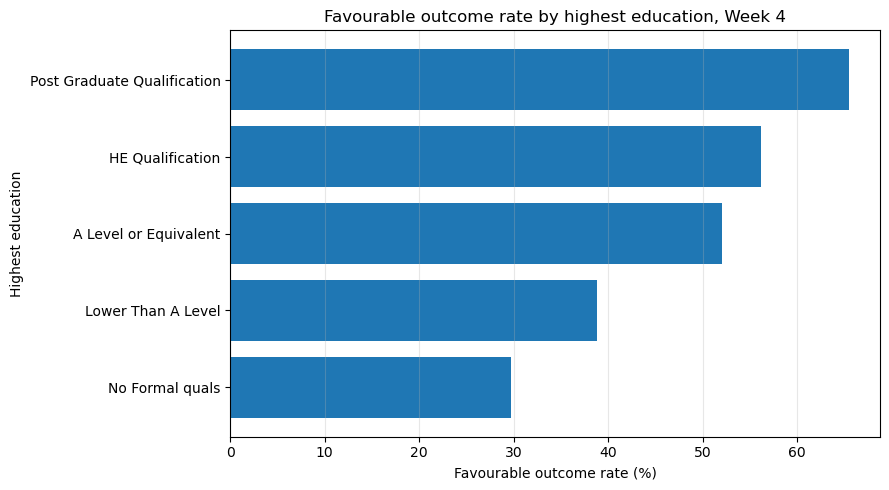

Saved: results/eda_week4_highest_education_outcome_rate.png
Saved: results/eda_week4_highest_education_outcome_rate.csv


,highest_education,favourable_rate_percent
0,No Formal quals,29.682997
1,Lower Than A Level,38.850889
2,A Level or Equivalent,52.032752
3,HE Qualification,56.173362
4,Post Graduate Qualification,65.495208


In [8]:
# EDA Figure 5: Favourable outcome rate by highest education, if available
week_for_category = "week4"
df_cat = load_week_df(week_for_category)

if "highest_education" not in df_cat.columns:
    print("highest_education column not found, skipping this EDA figure.")
else:
    edu_rate = (
        df_cat
        .groupby("highest_education")[TARGET]
        .mean()
        .sort_values()
        .mul(100)
        .reset_index()
    )
    edu_rate.columns = ["highest_education", "favourable_rate_percent"]

    plt.figure(figsize=(9, 5))
    plt.barh(edu_rate["highest_education"], edu_rate["favourable_rate_percent"])
    plt.xlabel("Favourable outcome rate (%)")
    plt.ylabel("Highest education")
    plt.title("Favourable outcome rate by highest education, Week 4")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/eda_week4_highest_education_outcome_rate.png", dpi=200)
    plt.show()

    edu_rate.to_csv("results/eda_week4_highest_education_outcome_rate.csv", index=False)
    print("Saved: results/eda_week4_highest_education_outcome_rate.png")
    print("Saved: results/eda_week4_highest_education_outcome_rate.csv")
    display(edu_rate)


## 4. Optional: view Task 4 baseline results and saved model inspection

In [9]:
if task4_results_path is not None:
    task4_baseline_results = pd.read_csv(task4_results_path)
    display(task4_baseline_results.head())
else:
    task4_baseline_results = None
    print("No Task 4 results CSV found.")

if model_inspection_path is not None:
    model_inspection = pd.read_csv(model_inspection_path)
    display(model_inspection[[
        "file", "loaded_successfully", "object_type", "is_pipeline",
        "pipeline_steps", "has_predict", "has_predict_proba", "n_features_in", "load_error"
    ]])
else:
    model_inspection = None
    print("No model inspection summary found.")


No Task 4 results CSV found.
No model inspection summary found.


## 5. Modelling helper functions

These helpers keep preprocessing inside the sklearn pipeline, so imputation, encoding, and scaling are fitted only on the training fold during CV.


In [10]:
def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_bagging_logreg():
    base_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    try:
        return BaggingClassifier(
            estimator=base_model,
            n_estimators=10,
            random_state=RANDOM_STATE,
        )
    except TypeError:
        return BaggingClassifier(
            base_estimator=base_model,
            n_estimators=10,
            random_state=RANDOM_STATE,
        )

def infer_columns(X: pd.DataFrame):
    categorical_cols = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=["int64", "int32", "float64", "float32", "Int64"]).columns.tolist()
    return categorical_cols, numeric_cols

def build_onehot_preprocessor(X: pd.DataFrame, scale_numeric=True):
    categorical_cols, numeric_cols = infer_columns(X)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder()),
    ])

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    transformers = []
    if categorical_cols:
        transformers.append(("cat", categorical_pipeline, categorical_cols))
    if numeric_cols:
        transformers.append(("num", numeric_pipeline, numeric_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

def build_ordinal_preprocessor(X: pd.DataFrame, scale_numeric=True):
    categorical_cols, numeric_cols = infer_columns(X)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    transformers = []
    if categorical_cols:
        transformers.append(("cat", categorical_pipeline, categorical_cols))
    if numeric_cols:
        transformers.append(("num", numeric_pipeline, numeric_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

def build_target_preprocessor(X: pd.DataFrame, scale_numeric=True):
    if not HAS_TARGET_ENCODER:
        raise RuntimeError("TargetEncoder is not available in this sklearn version.")

    categorical_cols, numeric_cols = infer_columns(X)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target", TargetEncoder(random_state=RANDOM_STATE)),
    ])

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    transformers = []
    if categorical_cols:
        transformers.append(("cat", categorical_pipeline, categorical_cols))
    if numeric_cols:
        transformers.append(("num", numeric_pipeline, numeric_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc",
}

def evaluate_pipeline_cv(X, y, pipeline, cv):
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=SCORING,
        error_score="raise",
        n_jobs=None,
    )

    record = {}
    for metric in SCORING:
        values = scores[f"test_{metric}"]
        record[f"{metric}_mean"] = float(np.mean(values))
        record[f"{metric}_std"] = float(np.std(values))
    return record

def round_record(record, digits=4):
    return {k: round(v, digits) if isinstance(v, float) else v for k, v in record.items()}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


## 6. Official Task 4 baseline families, now evaluated with 5-fold CV

The latest Task 4 script uses six baseline model families:

- B1 Logistic Regression
- B2 L1-Regularised Logistic Regression
- B3 SGD Logistic
- B4 KNN
- B5 Gaussian Naive Bayes
- B6 Bagging Logistic Regression

The original Task 4 output used an 80/20 stratified split. In this notebook, the same model families are re-evaluated using 5-fold stratified CV for Task 6.


In [ ]:
def task4_baseline_model_factories():
    return {
        "B1_LogisticRegression": lambda: LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
        "B2_L1_Regularised_LogisticRegression": lambda: LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
        "B3_SGD_Logistic": lambda: SGDClassifier(
            loss="log_loss",
            max_iter=2000,
            tol=1e-3,
            random_state=RANDOM_STATE,
        ),
        "B4_KNN": lambda: KNeighborsClassifier(
            n_neighbors=15,
        ),
        "B5_GaussianNB": lambda: GaussianNB(),
        "B6_Bagging_LogisticRegression": make_bagging_logreg,
    }

task4_cv_records = []

for week in WEEKS:
    df = load_week_df(week)
    X, y = split_xy(df)

    print(f"\n[{week.upper()}]")
    for model_name, factory in task4_baseline_model_factories().items():
        model = factory()
        preprocessor = build_onehot_preprocessor(X, scale_numeric=True)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        result = evaluate_pipeline_cv(X, y, pipeline, cv)
        print(
            f"{model_name:<42} "
            f"AUC={result['auc_mean']:.4f}±{result['auc_std']:.4f}  "
            f"F1={result['f1_mean']:.4f}±{result['f1_std']:.4f}"
        )

        task4_cv_records.append({
            "week": week,
            "week_cutoff": WEEK_NUM[week],
            "pipeline_id": model_name,
            "model": model_name,
            "model_group": "Task 4 baseline",
            "feature_set": "Task 3 processed features",
            "preprocessing": "SimpleImputer + OneHotEncoder + StandardScaler",
            "evaluation_method": f"{CV_FOLDS}-fold stratified CV",
            "threshold": 0.5,
            "seed": RANDOM_STATE,
            **round_record(result),
        })

task4_cv_results = pd.DataFrame(task4_cv_records)
task4_cv_results.to_csv("results/task6_task4_baseline_cv_results.csv", index=False)
print("\nSaved: results/task6_task4_baseline_cv_results.csv")
task4_cv_results



[WEEK2]
B1_LogisticRegression                      AUC=0.7529±0.0033  F1=0.6464±0.0053
B2_L1_Regularised_LogisticRegression       AUC=0.7529±0.0032  F1=0.6459±0.0051
B3_SGD_Logistic                            AUC=0.7485±0.0045  F1=0.6322±0.0523
B4_KNN                                     AUC=0.7339±0.0058  F1=0.6474±0.0035
B5_GaussianNB                              AUC=0.6997±0.0045  F1=0.4451±0.0120
B6_Bagging_LogisticRegression              AUC=0.7528±0.0031  F1=0.6462±0.0044

[WEEK4]
B1_LogisticRegression                      AUC=0.7724±0.0043  F1=0.6664±0.0033
B2_L1_Regularised_LogisticRegression       AUC=0.7724±0.0043  F1=0.6665±0.0037
B3_SGD_Logistic                            AUC=0.7685±0.0062  F1=0.6731±0.0186
B4_KNN                                     AUC=0.7534±0.0066  F1=0.6661±0.0065
B5_GaussianNB                              AUC=0.7103±0.0036  F1=0.4821±0.0121
B6_Bagging_LogisticRegression              AUC=0.7723±0.0042  F1=0.6662±0.0041

[WEEK6]
B1_LogisticRegression    

## 7. Task 6 baseline/advanced comparison models

These models are useful for pipeline comparison beyond the taught Task 4 baseline families.


In [ ]:
def extra_model_factories():
    factories = {
        "LR_weighted_onehot": lambda: (
            "SimpleImputer + OneHotEncoder + StandardScaler",
            build_onehot_preprocessor,
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        ),
        "RandomForest_ordinal": lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
        "GradientBoosting_ordinal": lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            GradientBoostingClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
            ),
        ),
    }

    if HAS_CALIBRATION:
        factories["RF_calibrated_Task5_style"] = lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            CalibratedClassifierCV(
                estimator=RandomForestClassifier(
                    n_estimators=100,
                    max_depth=10,
                    max_features="sqrt",
                    min_samples_leaf=2,
                    min_samples_split=5,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
                method="sigmoid",
                cv=5,
            ),
        )

    factories["GBM_Task5_style"] = lambda: (
        "SimpleImputer + OrdinalEncoder + StandardScaler",
        build_ordinal_preprocessor,
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=RANDOM_STATE,
        ),
    )

    factories["RF_weighted_Task5_style"] = lambda: (
        "SimpleImputer + OrdinalEncoder + StandardScaler",
        build_ordinal_preprocessor,
        RandomForestClassifier(
            n_estimators=100,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    )

    factories["KNN_Task5_style"] = lambda: (
        "SimpleImputer + OneHotEncoder + StandardScaler",
        build_onehot_preprocessor,
        KNeighborsClassifier(n_neighbors=5),
    )

    if HAS_XGBOOST:
        factories["XGBoost_Task5_style"] = lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            XGBClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                eval_metric="logloss",
                verbosity=0,
                n_jobs=-1,
            ),
        )

    if HAS_CATBOOST:
        factories["CatBoost_Task5_style"] = lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            CatBoostClassifier(
                iterations=300,
                depth=6,
                learning_rate=0.05,
                loss_function="Logloss",
                eval_metric="AUC",
                auto_class_weights="Balanced",
                random_state=RANDOM_STATE,
                verbose=False,
            ),
        )

    return factories

extra_cv_records = []

for week in WEEKS:
    df = load_week_df(week)
    X, y = split_xy(df)

    print(f"\n[{week.upper()}]")
    for model_name, factory in extra_model_factories().items():
        preprocessing_name, preprocessor_factory, model = factory()
        preprocessor = preprocessor_factory(X, scale_numeric=True)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        result = evaluate_pipeline_cv(X, y, pipeline, cv)
        print(
            f"{model_name:<34} "
            f"AUC={result['auc_mean']:.4f}±{result['auc_std']:.4f}  "
            f"F1={result['f1_mean']:.4f}±{result['f1_std']:.4f}"
        )

        extra_cv_records.append({
            "week": week,
            "week_cutoff": WEEK_NUM[week],
            "pipeline_id": model_name,
            "model": model_name,
            "model_group": "Task 6 / Task 5-style comparison",
            "feature_set": "Task 3 processed features",
            "preprocessing": preprocessing_name,
            "evaluation_method": f"{CV_FOLDS}-fold stratified CV",
            "threshold": 0.5,
            "seed": RANDOM_STATE,
            **round_record(result),
        })

extra_cv_results = pd.DataFrame(extra_cv_records)
extra_cv_results.to_csv("results/task6_extra_model_cv_results.csv", index=False)
print("\nSaved: results/task6_extra_model_cv_results.csv")
extra_cv_results


## 8. Combined pipeline comparison table

In [ ]:
all_cv_results = pd.concat([task4_cv_results, extra_cv_results], ignore_index=True)
all_cv_results.to_csv("results/task6_all_cv_results.csv", index=False)

pipeline_comparison_table = all_cv_results[[
    "pipeline_id", "week_cutoff", "feature_set", "preprocessing",
    "model", "model_group", "evaluation_method", "threshold", "seed",
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "auc_mean",
    "accuracy_std", "precision_std", "recall_std", "f1_std", "auc_std",
]].copy()

pipeline_comparison_table.to_csv("results/task6_pipeline_comparison_table.csv", index=False)

best_pipeline_per_week = (
    all_cv_results
    .sort_values(["week_cutoff", "auc_mean", "f1_mean"], ascending=[True, False, False])
    .groupby("week_cutoff", as_index=False)
    .first()
)

best_pipeline_per_week["brief_takeaway"] = best_pipeline_per_week.apply(
    lambda row: f"{row['model']} achieved the highest mean AUC at week {row['week_cutoff']}.",
    axis=1,
)

best_pipeline_per_week.to_csv("results/task6_best_pipeline_per_week.csv", index=False)

print("Saved:")
print("- results/task6_all_cv_results.csv")
print("- results/task6_pipeline_comparison_table.csv")
print("- results/task6_best_pipeline_per_week.csv")

display(best_pipeline_per_week[[
    "week_cutoff", "pipeline_id", "model", "model_group",
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "auc_mean",
    "threshold", "brief_takeaway"
]])


## 8B. Brief-required Table 2.4: Experiments table

This table is formatted to match the brief requirement more closely.

It explicitly includes:

- whether hyperparameters were changed,
- which metrics were computed,
- notes explaining the experiment purpose.


In [ ]:
def hyperparameter_changed_flag(pipeline_id: str) -> str:
    no_major_tuning = {
        "B1_LogisticRegression",
        "B5_GaussianNB",
    }
    return "No major tuning" if pipeline_id in no_major_tuning else "Yes"

def hyperparameter_notes(pipeline_id: str) -> str:
    notes = {
        "B1_LogisticRegression": "Mostly default Logistic Regression; max_iter and random_state set for convergence/reproducibility.",
        "B2_L1_Regularised_LogisticRegression": "L1 penalty and liblinear solver used.",
        "B3_SGD_Logistic": "SGD logistic model uses log_loss, max_iter, tolerance, and random_state.",
        "B4_KNN": "KNN uses n_neighbors=15.",
        "B5_GaussianNB": "GaussianNB used with default settings.",
        "B6_Bagging_LogisticRegression": "Bagging ensemble uses Logistic Regression base estimator and n_estimators=10.",
        "LR_weighted_onehot": "Logistic Regression uses class_weight='balanced'.",
        "RandomForest_ordinal": "Random Forest uses n_estimators=200 and class_weight='balanced'.",
        "GradientBoosting_ordinal": "Gradient Boosting uses n_estimators=200.",
        "RF_calibrated_Task5_style": "Random Forest wrapped in calibrated classifier using sigmoid calibration.",
        "GBM_Task5_style": "Gradient Boosting uses Task 5-style settings.",
        "RF_weighted_Task5_style": "Random Forest uses class_weight='balanced' and Task 5-style settings.",
        "KNN_Task5_style": "KNN uses Task 5-style n_neighbors setting.",
        "XGBoost_Task5_style": "XGBoost uses n_estimators and eval_metric settings.",
        "CatBoost_Task5_style": "CatBoost uses depth, learning rate, iterations, AUC eval metric, and balanced class weights.",
    }
    return notes.get(pipeline_id, "Model hyperparameters recorded in the notebook pipeline definition.")

def experiment_note(row) -> str:
    if row["model_group"] == "Task 4 baseline":
        return "Task 4 baseline family re-evaluated using 5-fold stratified CV."
    return "Task 5-style or Task 6 comparison model evaluated using the same CV protocol."

table_2_4_experiments = all_cv_results.copy()
table_2_4_experiments["Experiment ID"] = [
    f"EXP_{i+1:03d}" for i in range(len(table_2_4_experiments))
]
table_2_4_experiments["Hyperparameters changed?"] = table_2_4_experiments["pipeline_id"].apply(hyperparameter_changed_flag)
table_2_4_experiments["Hyperparameter notes"] = table_2_4_experiments["pipeline_id"].apply(hyperparameter_notes)
table_2_4_experiments["Metrics computed"] = "Accuracy, Precision, Recall, F1, AUC"
table_2_4_experiments["Notes"] = table_2_4_experiments.apply(experiment_note, axis=1)

table_2_4_experiments = table_2_4_experiments[[
    "Experiment ID",
    "week_cutoff",
    "pipeline_id",
    "model_group",
    "model",
    "feature_set",
    "evaluation_method",
    "threshold",
    "seed",
    "Hyperparameters changed?",
    "Hyperparameter notes",
    "Metrics computed",
    "Notes",
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "auc_mean",
]]

table_2_4_experiments.to_csv("results/task6_table_2_4_experiments.csv", index=False)
print("Saved: results/task6_table_2_4_experiments.csv")
table_2_4_experiments


## 8C. Brief-required Table 2.5: Pipeline comparison table

This version separates **Encoding** and **Scaling** into their own columns instead of hiding them inside one preprocessing string.


In [ ]:
def extract_encoding(preprocessing: str) -> str:
    text = str(preprocessing)
    if "OneHotEncoder" in text:
        return "One-hot encoding"
    if "OrdinalEncoder" in text:
        return "Ordinal encoding"
    if "TargetEncoder" in text:
        return "Target encoding"
    return "Not specified"

def extract_scaling(preprocessing: str) -> str:
    text = str(preprocessing)
    if "StandardScaler" in text:
        return "StandardScaler"
    return "No scaling specified"

def extract_imputation(preprocessing: str) -> str:
    text = str(preprocessing)
    if "SimpleImputer" in text:
        return "SimpleImputer"
    return "Not specified"

table_2_5_pipeline_comparison = all_cv_results.copy()
table_2_5_pipeline_comparison["Encoding"] = table_2_5_pipeline_comparison["preprocessing"].apply(extract_encoding)
table_2_5_pipeline_comparison["Scaling"] = table_2_5_pipeline_comparison["preprocessing"].apply(extract_scaling)
table_2_5_pipeline_comparison["Imputation"] = table_2_5_pipeline_comparison["preprocessing"].apply(extract_imputation)
table_2_5_pipeline_comparison["Metrics computed"] = "Accuracy, Precision, Recall, F1, AUC"

table_2_5_pipeline_comparison = table_2_5_pipeline_comparison[[
    "pipeline_id",
    "week_cutoff",
    "feature_set",
    "model",
    "model_group",
    "Imputation",
    "Encoding",
    "Scaling",
    "evaluation_method",
    "threshold",
    "Metrics computed",
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "auc_mean",
    "accuracy_std",
    "precision_std",
    "recall_std",
    "f1_std",
    "auc_std",
]]

table_2_5_pipeline_comparison.to_csv("results/task6_table_2_5_pipeline_comparison.csv", index=False)
print("Saved: results/task6_table_2_5_pipeline_comparison.csv")
table_2_5_pipeline_comparison


## 9. Feature-drop ablation

Ablation asks: *what happens if we remove this feature group?*

A large negative AUC delta means the removed feature group is important.


In [ ]:
def vle_base_cols(week):
    return [f"total_clicks_{week}", f"active_days_{week}"]

def vle_activity_cols(week):
    return [f"{act}_clicks_{week}" for act in VLE_ACT_TYPES]

def existing(cols, X):
    return [c for c in cols if c in X.columns]

feature_ablation_records = []

for week in WEEKS:
    df = load_week_df(week)
    X_full, y = split_xy(df)

    demo_cols = existing(DEMO_CAT_COLS + DEMO_NUM_COLS, X_full)
    vle_base = existing(vle_base_cols(week), X_full)
    vle_activity = existing(vle_activity_cols(week), X_full)
    vle_all = vle_base + vle_activity

    configs = [
        ("baseline (all features)", X_full.columns.tolist()),
        ("drop student demographics", [c for c in X_full.columns if c not in demo_cols]),
        ("drop VLE features", [c for c in X_full.columns if c not in vle_all]),
        ("drop activity types — keep total + active_days", [c for c in X_full.columns if c not in vle_activity]),
        ("drop total + active_days — keep activity types", [c for c in X_full.columns if c not in vle_base]),
    ]

    for col in existing(DEMO_CAT_COLS + DEMO_NUM_COLS, X_full):
        configs.append((f"drop {col}", [c for c in X_full.columns if c != col]))

    print(f"\n[{week.upper()}]")
    for config_name, columns_used in configs:
        X = X_full[columns_used].copy()

        preprocessor = build_ordinal_preprocessor(X, scale_numeric=True)
        model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        result = evaluate_pipeline_cv(X, y, pipeline, cv)
        print(f"{config_name:<55} AUC={result['auc_mean']:.4f}±{result['auc_std']:.4f}")

        feature_ablation_records.append({
            "week": week,
            "week_cutoff": WEEK_NUM[week],
            "experiment": "feature_drop",
            "configuration": config_name,
            "model": "Random Forest",
            "preprocessing": "SimpleImputer + OrdinalEncoder + StandardScaler",
            "evaluation_method": f"{CV_FOLDS}-fold stratified CV",
            "seed": RANDOM_STATE,
            **round_record(result),
        })

feature_ablation = pd.DataFrame(feature_ablation_records)

# Add deltas relative to the baseline for each week.
baseline_lookup = (
    feature_ablation[feature_ablation["configuration"] == "baseline (all features)"]
    .set_index("week")
)

for metric in ["accuracy", "precision", "recall", "f1", "auc"]:
    feature_ablation[f"{metric}_delta"] = feature_ablation.apply(
        lambda row: round(row[f"{metric}_mean"] - baseline_lookup.loc[row["week"], f"{metric}_mean"], 4),
        axis=1,
    )

feature_ablation.to_csv("results/task6_feature_ablation_results.csv", index=False)
print("\nSaved: results/task6_feature_ablation_results.csv")
feature_ablation


## 10. Encoding ablation

In [ ]:
encoding_ablation_records = []
encoding_factories = {
    "ordinal": build_ordinal_preprocessor,
    "onehot": build_onehot_preprocessor,
}

if HAS_TARGET_ENCODER:
    encoding_factories["target"] = build_target_preprocessor

models_for_encoding = {
    "LogisticRegression_weighted": lambda: LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "RandomForest_weighted": lambda: RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

for week in WEEKS:
    df = load_week_df(week)
    X, y = split_xy(df)

    print(f"\n[{week.upper()}]")
    for encoding_name, preprocessor_factory in encoding_factories.items():
        for model_name, model_factory in models_for_encoding.items():
            preprocessor = preprocessor_factory(X, scale_numeric=True)
            model = model_factory()

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model),
            ])

            result = evaluate_pipeline_cv(X, y, pipeline, cv)
            print(
                f"{model_name + ' / ' + encoding_name:<45} "
                f"AUC={result['auc_mean']:.4f}±{result['auc_std']:.4f}"
            )

            encoding_ablation_records.append({
                "week": week,
                "week_cutoff": WEEK_NUM[week],
                "experiment": "encoding",
                "configuration": f"{model_name} / {encoding_name}",
                "model": model_name,
                "encoding": encoding_name,
                "evaluation_method": f"{CV_FOLDS}-fold stratified CV",
                "seed": RANDOM_STATE,
                **round_record(result),
            })

encoding_ablation = pd.DataFrame(encoding_ablation_records)
encoding_ablation.to_csv("results/task6_encoding_ablation_results.csv", index=False)
print("\nSaved: results/task6_encoding_ablation_results.csv")
encoding_ablation


## 11. Report-ready ablation table

In [ ]:
report_ablation_table = feature_ablation[[
    "week_cutoff", "configuration", "model",
    "auc_mean", "auc_delta", "f1_mean", "f1_delta",
]].copy()

report_ablation_table["baseline_pipeline"] = "Random Forest baseline"
report_ablation_table["changed_pipeline"] = report_ablation_table["configuration"]
report_ablation_table["metric_impacted_most"] = "AUC"
report_ablation_table["result_direction_magnitude"] = report_ablation_table["auc_delta"].apply(lambda x: f"{x:+.4f}")

def interpret_ablation(row):
    config = row["configuration"]
    delta = row["auc_delta"]
    if config == "baseline (all features)":
        return "Reference pipeline for comparison."
    if "drop VLE features" in config:
        return "Large drop indicates VLE engagement is highly important."
    if "drop student demographics" in config:
        return "Demographics add useful information, but less than VLE behaviour."
    if abs(delta) < 0.005:
        return "Small change suggests limited individual impact."
    if delta < 0:
        return "Performance decreased, so the removed feature contributes useful signal."
    return "Performance did not decrease, suggesting the removed feature may be less useful."

report_ablation_table["interpretation"] = report_ablation_table.apply(interpret_ablation, axis=1)

report_ablation_table = report_ablation_table[[
    "week_cutoff", "baseline_pipeline", "changed_pipeline",
    "metric_impacted_most", "result_direction_magnitude",
    "auc_mean", "auc_delta", "f1_mean", "f1_delta", "interpretation",
]]

report_ablation_table.to_csv("results/task6_report_ablation_table.csv", index=False)
print("Saved: results/task6_report_ablation_table.csv")
report_ablation_table


## 12. Figures

In [ ]:
# Figure 1: AUC by week for all CV models
plot_df = all_cv_results.copy()

plt.figure(figsize=(11, 6))
for model_name, group in plot_df.groupby("pipeline_id"):
    group = group.sort_values("week_cutoff")
    plt.plot(group["week_cutoff"], group["auc_mean"], marker="o", label=model_name)

plt.xlabel("Week cutoff")
plt.ylabel("Mean AUC")
plt.title("Pipeline comparison: mean AUC by week cutoff")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("results/task6_pipeline_auc_by_week.png", dpi=200)
plt.show()

print("Saved: results/task6_pipeline_auc_by_week.png")


In [ ]:
# Figure 2: Best model per week
best_plot = best_pipeline_per_week.sort_values("week_cutoff")

plt.figure(figsize=(8, 5))
plt.plot(best_plot["week_cutoff"], best_plot["auc_mean"], marker="o")
plt.xlabel("Week cutoff")
plt.ylabel("Best mean AUC")
plt.title("Best cross-validated AUC per week cutoff")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/task6_best_auc_per_week.png", dpi=200)
plt.show()

print("Saved: results/task6_best_auc_per_week.png")


In [ ]:
# Figure 3: Week 4 feature-drop ablation
w4 = feature_ablation[
    (feature_ablation["week_cutoff"] == 4) &
    (feature_ablation["configuration"] != "baseline (all features)")
].sort_values("auc_delta")

plt.figure(figsize=(9, 6))
plt.barh(w4["configuration"], w4["auc_delta"])
plt.xlabel("AUC delta vs baseline")
plt.ylabel("Ablation configuration")
plt.title("Week 4 feature-drop ablation")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("results/task6_week4_feature_ablation.png", dpi=200)
plt.show()

print("Saved: results/task6_week4_feature_ablation.png")


In [ ]:
# Figure 4: Encoding ablation
enc_plot = encoding_ablation.copy()

plt.figure(figsize=(10, 5))
for config, group in enc_plot.groupby("configuration"):
    group = group.sort_values("week_cutoff")
    plt.plot(group["week_cutoff"], group["auc_mean"], marker="o", label=config)

plt.xlabel("Week cutoff")
plt.ylabel("Mean AUC")
plt.title("Encoding ablation: mean AUC by week cutoff")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("results/task6_encoding_ablation.png", dpi=200)
plt.show()

print("Saved: results/task6_encoding_ablation.png")


## 13. Written interpretation for the report

In [ ]:
best_overall = all_cv_results.sort_values(["auc_mean", "f1_mean"], ascending=False).iloc[0]

largest_drop = (
    feature_ablation[feature_ablation["configuration"] != "baseline (all features)"]
    .sort_values("auc_delta")
    .iloc[0]
)

text = f'''
Cross-validation was performed using {CV_FOLDS}-fold stratified cross-validation across the week 2, 4, 6, and 8 feature tables. 
The strongest overall pipeline was {best_overall["pipeline_id"]} at week {best_overall["week_cutoff"]}, with a mean AUC of {best_overall["auc_mean"]:.4f} and a mean F1 score of {best_overall["f1_mean"]:.4f}. 
The results generally improved as the week cutoff increased, which suggests that additional student activity data improves early at-risk prediction.

The feature-drop ablation study showed that the largest AUC decrease occurred for "{largest_drop["configuration"]}" at week {largest_drop["week_cutoff"]}, with an AUC delta of {largest_drop["auc_delta"]:+.4f}. 
This indicates that the removed feature group carries important predictive information. 
In particular, decreases after removing VLE engagement features show that online activity behaviour is a major contributor to the prediction task.

The encoding ablation compared ordinal, one-hot, and target encoding where available. 
One-hot encoding is especially important for linear models because it avoids imposing artificial numerical order on categorical variables. 
Tree-based models were generally less sensitive to the encoding choice, although the final choice should still be based on the cross-validated AUC and F1 results.
'''

print(text)
